In [110]:
pip install xgboost

In [111]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.pipeline import Pipeline

import joblib



##Load Dataset

In [112]:
df = pd.read_csv("diabetes_data_upload.csv")

##Understanding Data

In [113]:
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [115]:
df.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [116]:
df["class"].value_counts()

,count
class,
Positive,320
Negative,200


In [117]:
df.isnull().value_counts()

,,,,,,,,,,,,,,,,,count
Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class,
False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,520


##Handling The Data

In [118]:
# Binary Encoding

binary_columns = [
    "Polyuria",
    "Polydipsia",
    "sudden weight loss",
    "weakness",
    "Polyphagia",
    "Genital thrush",
    "visual blurring",
    "Itching",
    "Irritability",
    "delayed healing",
    "partial paresis",
    "muscle stiffness",
    "Alopecia",
    "Obesity"
]

# Yes / No → 1 / 0
df[binary_columns] = df[binary_columns].replace({
    "Yes": 1,
    "No": 0
})

# Gender → 1 / 0
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

# Target: Positive / Negative → 1 / 0
df["class"] = df["class"].map({
    "Positive": 1,
    "Negative": 0
})

/tmp/ipykernel_822/929594934.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace({


In [119]:
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


##EDA

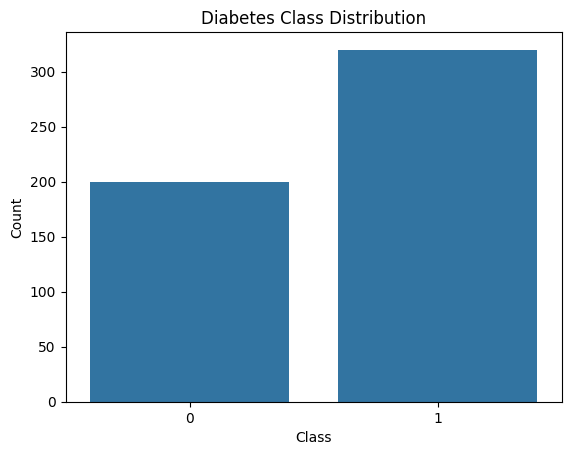

In [120]:
#Diabetes Class Distribution
sns.countplot(x="class", data=df)
plt.title("Diabetes Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

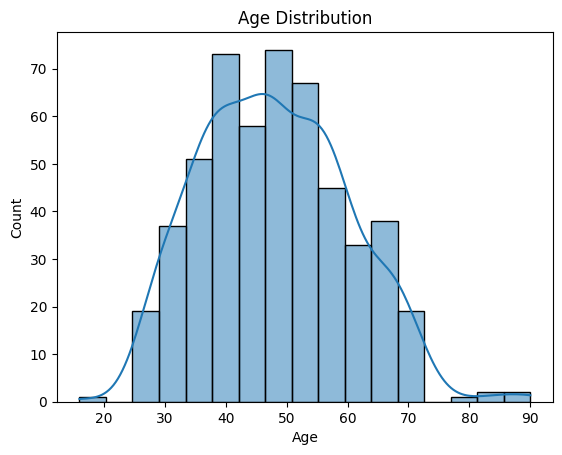

In [121]:
#Age Distribution
sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution")
plt.show()

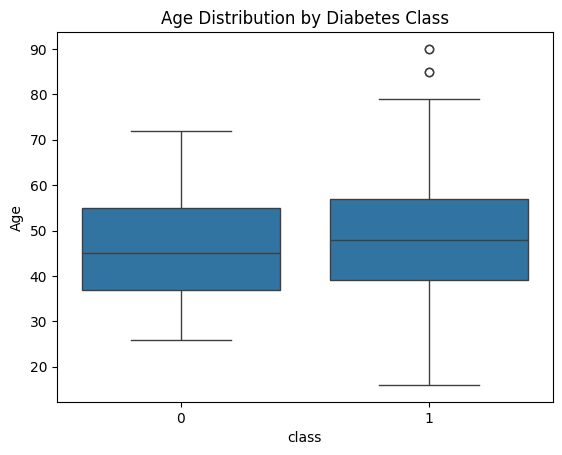

In [122]:
#Age Distribution by Diabetes Class
sns.boxplot(data=df, x="class", y="Age")
plt.title("Age Distribution by Diabetes Class")
plt.show()

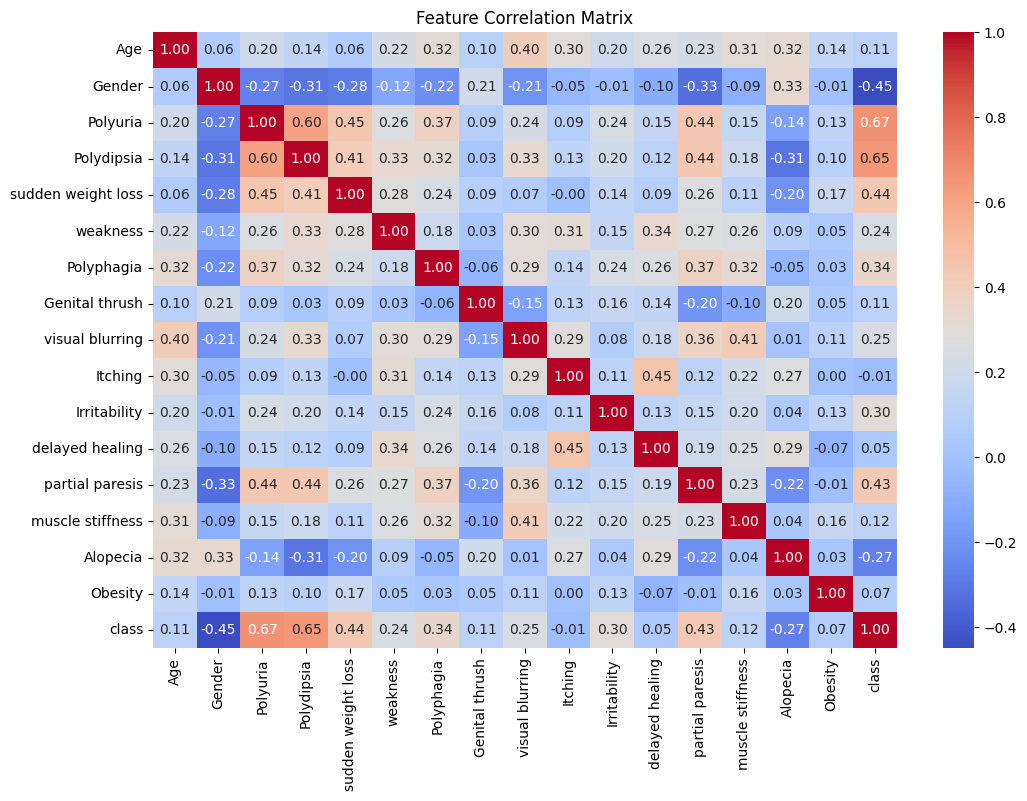

In [123]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [124]:
df.corr()["class"].sort_values(ascending=False)

,class
class,1.000000
Polyuria,0.665922
Polydipsia,0.648734
sudden weight loss,0.436568
partial paresis,0.432288
Polyphagia,0.342504
Irritability,0.299467
visual blurring,0.251300
weakness,0.243275
muscle stiffness,0.122474


##Data Cleaning

In [125]:
df.duplicated().sum()


np.int64(269)

In [126]:
df = df.drop_duplicates().reset_index(drop=True)

In [127]:
df.shape

(251, 17)

In [128]:
df["class"].value_counts()

,count
class,
1,173
0,78


##Train/Test Split

In [129]:
X=df.drop("class",axis = 1)
y=df["class"]

In [130]:
X_train , X_test , y_train, y_test =train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (200, 16)
X_test: (51, 16)
y_train: (200,)
y_test: (51,)


##Model_1

In [132]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

In [133]:
logistic_model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(random_state=42))])

In [134]:
y_pred_logistic = logistic_model.predict(X_test)
y_prop_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [135]:
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    y_prop_logistic
))

Accuracy : 0.803921568627451
Precision: 0.9310344827586207
Recall   : 0.7714285714285715
F1 Score : 0.84375
ROC-AUC  : 0.9196428571428571


In [136]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74        16
           1       0.93      0.77      0.84        35

    accuracy                           0.80        51
   macro avg       0.78      0.82      0.79        51
weighted avg       0.84      0.80      0.81        51



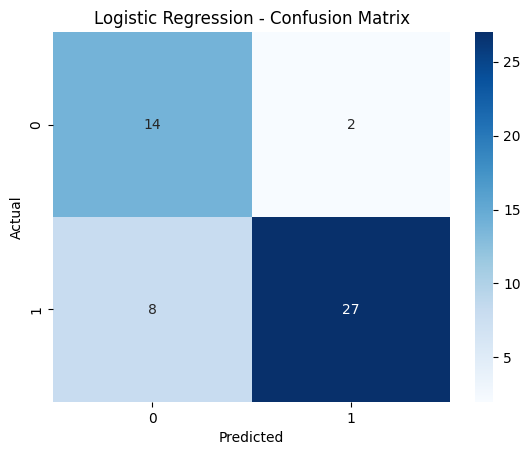

In [137]:
cm = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Model_2

In [138]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

In [139]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(probability=True, random_state=42))])

In [140]:
y_pred_svm = svm_model.predict(X_test)
y_prop_svm = svm_model.predict_proba(X_test)[:,1]

In [141]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    y_prop_svm
))

Accuracy : 0.9019607843137255
Precision: 0.96875
Recall   : 0.8857142857142857
F1 Score : 0.9253731343283582
ROC-AUC  : 0.9589285714285714


In [142]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       0.97      0.89      0.93        35

    accuracy                           0.90        51
   macro avg       0.88      0.91      0.89        51
weighted avg       0.91      0.90      0.90        51



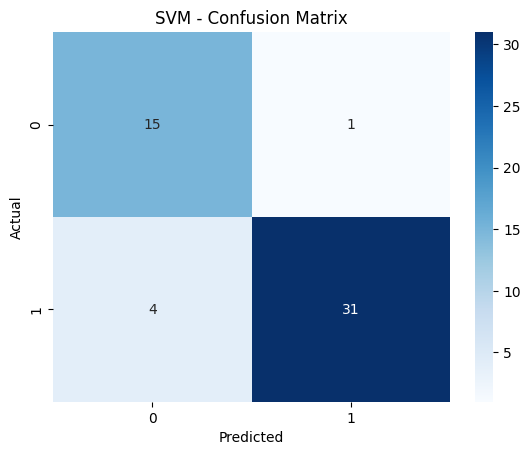

In [143]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Model_3

In [144]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


In [145]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [146]:
y_pred_rf = rf_model.predict(X_test)
y_prop_rf = rf_model.predict_proba(X_test)[:,1]

In [147]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    y_prop_rf
))

Accuracy : 0.9411764705882353
Precision: 1.0
Recall   : 0.9142857142857143
F1 Score : 0.9552238805970149
ROC-AUC  : 0.9678571428571429


In [148]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        16
           1       1.00      0.91      0.96        35

    accuracy                           0.94        51
   macro avg       0.92      0.96      0.93        51
weighted avg       0.95      0.94      0.94        51



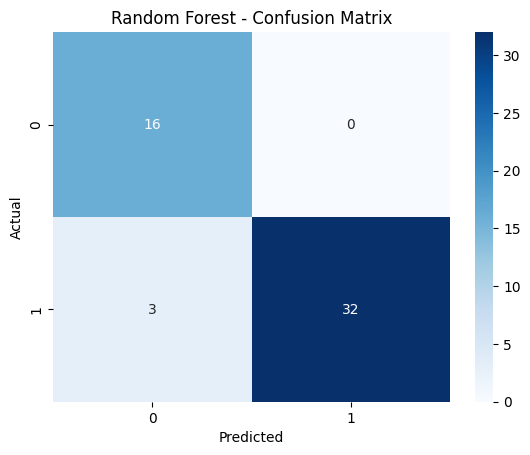

In [149]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

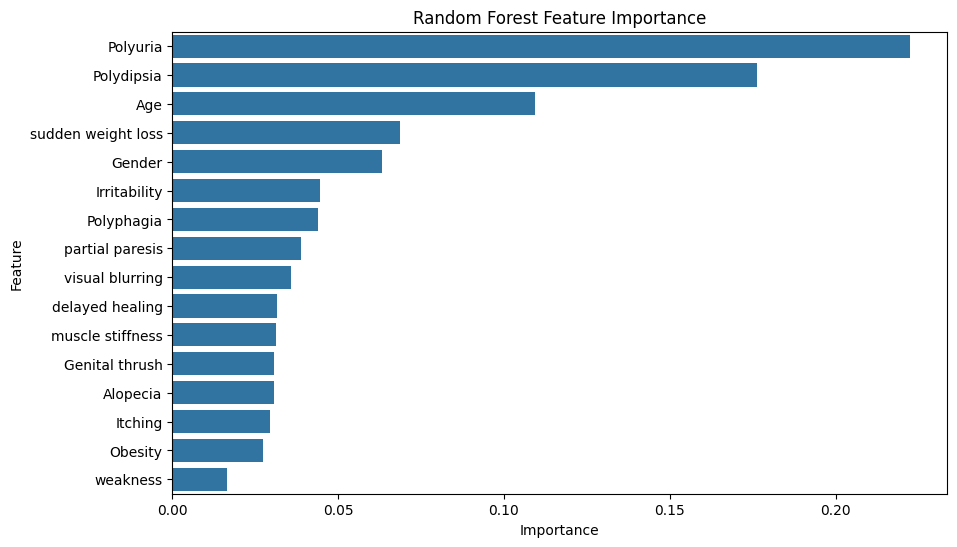

In [150]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

##Model_4

In [151]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

In [152]:
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [153]:
y_pred_xgb = xgb_model.predict(X_test)
y_prop_xgb = xgb_model.predict_proba(X_test)[:,1]

In [154]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(
    y_test,
    y_prop_xgb
))


Accuracy : 0.8823529411764706
Precision: 1.0
Recall   : 0.8285714285714286
F1 Score : 0.90625
ROC-AUC  : 0.9571428571428571


In [155]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84        16
           1       1.00      0.83      0.91        35

    accuracy                           0.88        51
   macro avg       0.86      0.91      0.87        51
weighted avg       0.91      0.88      0.89        51



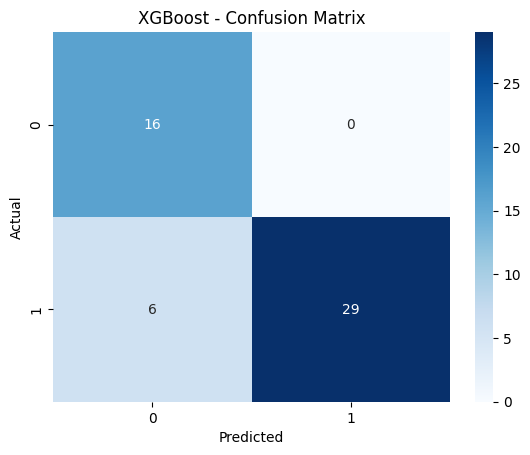

In [156]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

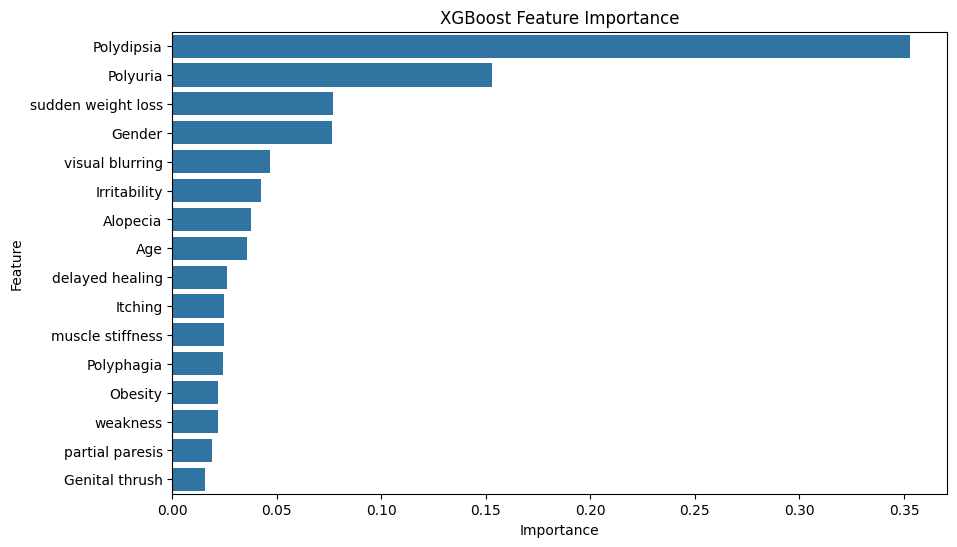

In [157]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

##Comparison

In [158]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, svm_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803922,0.931034,0.771429,0.843750,0.919643
1,SVM,0.901961,0.968750,0.885714,0.925373,0.958929
2,Random Forest,0.941176,1.000000,0.914286,0.955224,0.967857
3,XGBoost,0.882353,1.000000,0.828571,0.906250,0.957143


### Observation

Based on the initial test-set evaluation, Random Forest achieved the best overall performance with an accuracy of 94.12%, F1 Score of 95.52%, and ROC-AUC of 96.79%.

It also achieved the highest recall (91.43%), which is particularly important for disease prediction because minimizing false negative cases is a key consideration.

However, these results were obtained from a single train-test split. Therefore, cross-validation is required to verify the stability and reliability of these results.

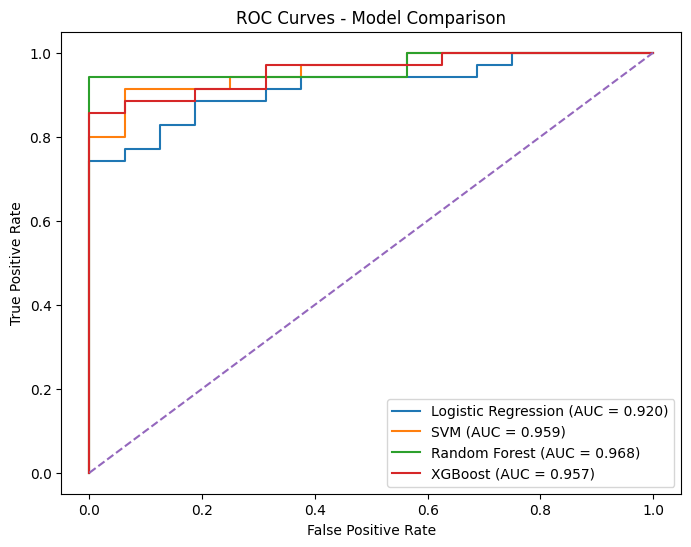

In [159]:
models_probabilities = {
    "Logistic Regression": logistic_model.predict_proba(X_test)[:, 1],
    "SVM": svm_model.predict_proba(X_test)[:, 1],
    "Random Forest": rf_model.predict_proba(X_test)[:, 1],
    "XGBoost": xgb_model.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(8, 6))

for name, y_prob in models_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curves - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Cross-Validation

In [160]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models
models = {
    "Logistic Regression": logistic_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Store results
cv_results = []

for name, model in models.items():

    accuracy = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    precision = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="precision"
    ).mean()

    recall = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="recall"
    ).mean()

    f1 = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    ).mean()

    roc_auc = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    ).mean()

    cv_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

# Create results DataFrame
cv_results = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

# Sort by F1 Score
cv_results = cv_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

# Display
cv_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.940314,0.950425,0.965546,0.957073,0.977719
1,XGBoost,0.904392,0.938888,0.925378,0.930002,0.961891
2,SVM,0.896549,0.918553,0.936471,0.926310,0.969616
3,Logistic Regression,0.872549,0.906036,0.913782,0.908140,0.955424


### Observation

The cross-validation results confirmed the strong performance of Random Forest.

Random Forest achieved the highest average performance across all evaluated metrics, with 94.03% accuracy, 96.55% recall, 95.71% F1 Score, and 97.77% ROC-AUC.

These results are consistent with the initial test-set evaluation, indicating that the strong performance of Random Forest is not dependent on a single data split.

Therefore, Random Forest was selected as the final model for the disease prediction task.

## Final Model Selection

In [161]:
# Final Random Forest Model

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train on the full dataset
final_model.fit(X, y)

RandomForestClassifier(n_estimators=200, random_state=42)

In [162]:
feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
Polyuria,0.214409
Polydipsia,0.181527
Age,0.105620
Gender,0.064369
sudden weight loss,0.058034
partial paresis,0.049014
Irritability,0.045431
visual blurring,0.039544
Polyphagia,0.038507
Alopecia,0.037207


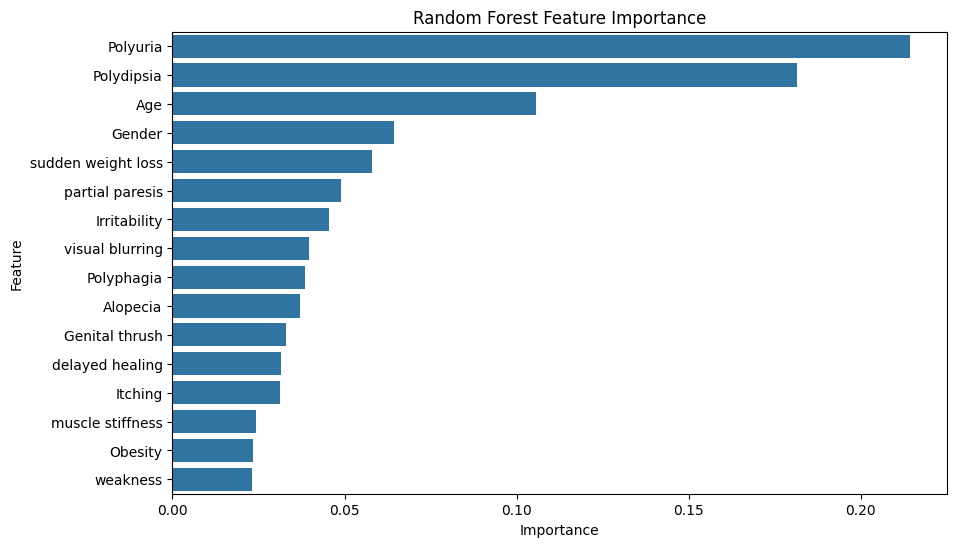

In [163]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [168]:
# Get new patient information

age = int(input("Enter Age: "))

gender = input("Enter Gender (Male/Female): ").strip().lower()

polyuria = input("Polyuria (Yes/No): ").strip().lower()
polydipsia = input("Polydipsia (Yes/No): ").strip().lower()
sudden_weight_loss = input("Sudden weight loss (Yes/No): ").strip().lower()
weakness = input("Weakness (Yes/No): ").strip().lower()
polyphagia = input("Polyphagia (Yes/No): ").strip().lower()
genital_thrush = input("Genital thrush (Yes/No): ").strip().lower()
visual_blurring = input("Visual blurring (Yes/No): ").strip().lower()
itching = input("Itching (Yes/No): ").strip().lower()
irritability = input("Irritability (Yes/No): ").strip().lower()
delayed_healing = input("Delayed healing (Yes/No): ").strip().lower()
partial_paresis = input("Partial paresis (Yes/No): ").strip().lower()
muscle_stiffness = input("Muscle stiffness (Yes/No): ").strip().lower()
alopecia = input("Alopecia (Yes/No): ").strip().lower()
obesity = input("Obesity (Yes/No): ").strip().lower()


# Encoding
gender = 1 if gender == "male" else 0

binary_inputs = [
    polyuria,
    polydipsia,
    sudden_weight_loss,
    weakness,
    polyphagia,
    genital_thrush,
    visual_blurring,
    itching,
    irritability,
    delayed_healing,
    partial_paresis,
    muscle_stiffness,
    alopecia,
    obesity
]

binary_inputs = [1 if value == "yes" else 0 for value in binary_inputs]


# Create DataFrame
new_patient = pd.DataFrame([[
    age,
    gender,
    *binary_inputs
]], columns=X.columns)


# Prediction
prediction = final_model.predict(new_patient)[0]

probability = final_model.predict_proba(new_patient)[0][1]


# Display patient data
print("\nPatient Data:")
display(new_patient)

print("\nPrediction:")

if prediction == 1:
    print("Positive")
else:
    print("Negative")

print(f"Positive Probability: {probability * 100:.2f}%")

Enter Age: 20
Enter Gender (Male/Female): male
Polyuria (Yes/No): no
Polydipsia (Yes/No): no
Sudden weight loss (Yes/No): no
Weakness (Yes/No): no
Polyphagia (Yes/No): no
Genital thrush (Yes/No): no
Visual blurring (Yes/No): yes
Itching (Yes/No): no
Irritability (Yes/No): no
Delayed healing (Yes/No): no
Partial paresis (Yes/No): no
Muscle stiffness (Yes/No): no
Alopecia (Yes/No): no
Obesity (Yes/No): no

Patient Data:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,20,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0



Prediction:
Negative
Positive Probability: 33.50%


##Save The Model

In [169]:
import joblib

joblib.dump(final_model, "diabetes_random_forest_model.pkl")

['diabetes_random_forest_model.pkl']

In [171]:
loaded_model = joblib.load("diabetes_random_forest_model.pkl")

In [172]:
from google.colab import files

files.download("diabetes_random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>